# EFT Diagnostics: Pure GB, Pure $g_2$, and Mixed

Weak-coupling diagnostics and hyperbolicity checks organised by coupling regime:
1. **Pure GB** — $\lambda_{\rm GB} \neq 0$, $g_2 = 0$
2. **Pure $g_2$** — $\lambda_{\rm GB} = 0$, $g_2 \neq 0$
3. **Mixed GB + $g_2$** — $\lambda_{\rm GB} \neq 0$, $g_2 \neq 0$

In [1]:
import sys, os, re, glob
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), "..", ".."))
sys.path.insert(0, PROJECT_ROOT)

from core.grid import Grid
from core.spacing import CubicSpacing
from core.statevector import StateVector
from matter.scalarmatter_MG import ScalarMatter
from backgrounds.sphericalbackground import FlatSphericalBackground
from bssn.oscillondiagnostic import get_oscillon_diagnostic
from bssn.EFTdiagnostic import get_eft_diagnostic

DATA_DIR = os.path.join(os.environ.get("VSC_DATA", os.getcwd()), "oscillon_runs")
print(f"DATA_DIR = {DATA_DIR}")

DATA_DIR = /data/leuven/384/vsc38419/oscillon_runs


/vsc-hard-mounts/leuven-user/384/vsc38419/0scillons/February26Oscillons/Feb26/bssn/EFTdiagnostic.py:17: SyntaxWarning: invalid escape sequence '\p'
  """
/vsc-hard-mounts/leuven-user/384/vsc38419/0scillons/February26Oscillons/Feb26/bssn/EFTdiagnostic.py:111: SyntaxWarning: invalid escape sequence '\m'
  """


## 0 — Parameters

In [2]:
ALIGN_LNA = 2.0
ALIGN_METHOD = "last_cross"
LNA_MIN_SEARCH = 0.0

C_CROSS_LEVELS = {
    -0.02: 0.02,
    -0.05: 0.04,
    -0.1:  0.06,
    -0.5:  0.125,
}
C_CROSS_DEFAULT = 0.02

# This gives the time window over which you want to take the average to calculate the compactness
# and the mean.
LN_A_COMP_MIN = 2
LN_A_COMP_MAX = 3.6

scalar_mu = 1
r_max = 150
min_dr = 1 / 16
max_dr = 2
a_mg = 0.2
b_mg = 0.4
chi0 = 0.15

## 1 — Discover, load, and align all runs

Run key is now `(lgb, mu, beta, amp, width, g2)` to separate runs with different $g_2$.

In [3]:
def find_peak_lna(osc, lna_min=0.0):
    C = osc["C"]
    ln_a = osc["ln_a"]
    mask = ln_a > lna_min
    if not np.any(mask):
        return np.nan
    idx = np.where(mask)[0]
    peak = idx[np.argmin(C[idx])]
    return ln_a[peak]

def find_last_crossing_lna(osc, level, lna_min=0.0):
    C = osc["C"]
    ln_a = osc["ln_a"]
    mask = ln_a > lna_min
    if not np.any(mask):
        return np.nan
    idx = np.where(mask)[0]
    C_sub = C[idx]
    ln_a_sub = ln_a[idx]
    above = C_sub > level
    crossings = np.where(above[:-1] & ~above[1:])[0]
    if len(crossings) == 0:
        return np.nan
    last = crossings[-1]
    frac = (level - C_sub[last+1]) / (C_sub[last] - C_sub[last+1])
    return ln_a_sub[last] * frac + ln_a_sub[last+1] * (1 - frac)

def compactness_in_window(shifted_ln_a, C, lo=LN_A_COMP_MIN, hi=LN_A_COMP_MAX):
    mask = (shifted_ln_a >= lo) & (shifted_ln_a <= hi)
    if not np.any(mask):
        return np.nan, np.nan, np.nan, np.nan
    c = C[mask]
    return np.mean(c), np.min(c), np.max(c), np.std(c)


######## LOADING FILTERS ########
FILTER_A_MG = 0
FILTER_B_MG = 0
FILTER_DR   = 1/24
#1/36  # set to None to load all resolutions, or e.g. 1/24, 1/36
############################

all_runs = {}   # key = (lgb, mu, beta, amp, width, g2)

for run_dir in sorted(glob.glob(os.path.join(DATA_DIR, "lgb*"))):
    tag = os.path.basename(run_dir)
    if not os.path.exists(os.path.join(run_dir, "solution.npy")):
        continue

    m_lgb = re.search(r"lgb([0-9eE.+-]+)", tag)
    m_mu  = re.search(r"mu([0-9eE.+-]+)", tag)
    m_amp = re.search(r"_amp([0-9eE.+-]+)", tag)
    m_R   = re.search(r"_R([0-9eE.+-]+)", tag)
    if not m_lgb or not m_mu:
        continue
    lgb   = float(m_lgb.group(1))
    mu    = float(m_mu.group(1))
    amp   = float(m_amp.group(1)) if m_amp else -0.02
    width = float(m_R.group(1))   if m_R   else 3.0

    m_a = re.search(r"_a([0-9eE.+-]+)_b", tag)
    m_b = re.search(r"_b([0-9eE.+-]+)_amp", tag)
    tag_a = float(m_a.group(1)) if m_a else 0.2
    tag_b = float(m_b.group(1)) if m_b else 0.4

    m_dr = re.search(r"_dr([0-9eE.+-]+)", tag)
    tag_dr = float(m_dr.group(1)) if m_dr else 0.0625

    if FILTER_A_MG is not None and abs(tag_a - FILTER_A_MG) > 1e-10:
        continue
    if FILTER_B_MG is not None and abs(tag_b - FILTER_B_MG) > 1e-10:
        continue
    if FILTER_DR is not None and abs(tag_dr - FILTER_DR) > 1e-4:
        continue

    m_beta = re.search(r"quadratic_(\d+\.?\d*)", tag)
    if m_beta:
        beta = float(m_beta.group(1))
    elif re.search(r"_quadratic_g2", tag) or tag.endswith("_quadratic"):
        beta = 0.0
    else:
        beta = 250.0

    if "_linear" in tag:
        coupling = "linear"; beta = None
    elif m_beta:
        coupling = f"quadratic_{int(beta)}"
    else:
        coupling = "quadratic"

    # Extract g2: first from directory name, then from metadata, default 0.0
    g2_val = 0.0
    m_g2 = re.search(r"_g2([0-9eE.+-]+)", tag)
    if m_g2:
        g2_val = float(m_g2.group(1))
    else:
        meta_path = os.path.join(run_dir, "metadata.npz")
        if os.path.exists(meta_path):
            try:
                meta = dict(np.load(meta_path, allow_pickle=True))
                if "g2" in meta:
                    g2_val = float(meta["g2"])
            except Exception:
                pass

    # Grid must match the run that wrote solution.npy (notebook r_max/min_dr alone can differ).
    _meta_for_grid = os.path.join(run_dir, "metadata.npz")
    _meta_grid = dict(np.load(_meta_for_grid, allow_pickle=True)) if os.path.exists(_meta_for_grid) else {}
    run_r_max = float(_meta_grid.get("r_max", r_max))
    run_min_dr = float(_meta_grid.get("min_dr", tag_dr))
    run_max_dr = float(_meta_grid.get("max_dr", max_dr))

    sol = np.load(os.path.join(run_dir, "solution.npy"))
    t   = np.load(os.path.join(run_dir, "t.npy"))

    matter_i  = ScalarMatter(scalar_mu, mu)
    sv_i      = StateVector(matter_i)
    spacing_i = CubicSpacing(**CubicSpacing.get_parameters(run_r_max, run_min_dr, run_max_dr))
    grid_i    = Grid(spacing_i, sv_i)
    bg_i      = FlatSphericalBackground(grid_i.r)

    _npt = sol[0].ravel().size // sv_i.NUM_VARS
    if _npt != grid_i.num_points:
        raise ValueError(
            f"{tag}: solution N={_npt} vs grid N={grid_i.num_points} "
            f"(r_max={run_r_max}, min_dr={run_min_dr}). Check metadata or tag_dr."
        )

    params = (lgb, a_mg, b_mg, chi0, coupling, g2_val)

    diag_path = os.path.join(run_dir, "diagnostics.npz")
    if os.path.exists(diag_path):
        osc = dict(np.load(diag_path, allow_pickle=True))
    else:
        osc = get_oscillon_diagnostic(
            sol, t, grid_i, bg_i,
            ScalarMatter(scalar_mu, mu),
            params, surface_threshold=0.05, r_max_diag=100.0,
        )
        np.savez(diag_path, **osc)

    # Alignment
    if ALIGN_METHOD == "last_cross":
        cross_level = C_CROSS_LEVELS.get(amp, C_CROSS_DEFAULT)
        anchor_lna = find_last_crossing_lna(osc, level=cross_level, lna_min=LNA_MIN_SEARCH)
    else:
        anchor_lna = find_peak_lna(osc, lna_min=LNA_MIN_SEARCH)
    shift = ALIGN_LNA - anchor_lna if not np.isnan(anchor_lna) else 0.0
    shifted_ln_a = osc["ln_a"] + shift

    C_mean, C_min, C_max, C_std = compactness_in_window(shifted_ln_a, osc["C"])

    key = (lgb, mu, beta, amp, width, g2_val)
    all_runs[key] = dict(
        osc=osc, t=t, tag=tag, lgb=lgb, mu=mu, beta=beta,
        coupling=coupling, amp=amp, width=width, g2=g2_val, dr=tag_dr,
        shift=shift, shifted_ln_a=shifted_ln_a,
        C_mean=C_mean, C_min=C_min, C_max=C_max, C_std=C_std,
        run_dir=run_dir, run_r_max=run_r_max, run_min_dr=run_min_dr,
        run_max_dr=run_max_dr,
    )

    beta_str = f"beta={int(beta)}" if beta is not None else "linear"
    if np.isnan(C_mean):
        print(f"  lgb={lgb:6.1f}, g2={g2_val:g}, mu={mu}, {beta_str:>10s}, A={amp}, R={width}  "
              f"shift={shift:+.3f}  C: no data in window  ({len(t)} steps)")
    else:
        print(f"  lgb={lgb:6.1f}, g2={g2_val:g}, mu={mu}, {beta_str:>10s}, A={amp}, R={width}  "
              f"shift={shift:+.3f}  C={C_mean:.4e} [{C_min:.4e}, {C_max:.4e}]  ({len(t)} steps)")
    del sol

print(f"\nTotal: {len(all_runs)} run(s) loaded and aligned")

  lgb=  -1.0, g2=20, mu=0.08,     beta=0, A=-0.02, R=3.0  shift=+0.538  C=7.3091e-03 [4.3339e-03, 1.4466e-02]  (1000 steps)
  lgb=  -2.0, g2=20, mu=0.08,     beta=0, A=-0.02, R=3.0  shift=+0.536  C=7.2257e-03 [4.2847e-03, 1.3609e-02]  (1000 steps)
  lgb=  -3.0, g2=20, mu=0.08,     beta=0, A=-0.02, R=3.0  shift=+0.531  C=7.1473e-03 [4.2228e-03, 1.3554e-02]  (1000 steps)
  lgb=  -4.0, g2=20, mu=0.08,     beta=0, A=-0.02, R=3.0  shift=+0.526  C=7.0565e-03 [4.1713e-03, 1.3361e-02]  (1000 steps)
  lgb=  -5.0, g2=20, mu=0.08,     beta=0, A=-0.02, R=3.0  shift=+0.524  C=6.9630e-03 [4.1293e-03, 1.3226e-02]  (1000 steps)
  lgb=  -6.0, g2=20, mu=0.08,     beta=0, A=-0.02, R=3.0  shift=+0.490  C=6.8973e-03 [4.1234e-03, 1.2932e-02]  (1000 steps)
  lgb=  -7.0, g2=20, mu=0.08,     beta=0, A=-0.02, R=3.0  shift=+0.480  C=6.8087e-03 [4.0823e-03, 1.2883e-02]  (1000 steps)
  lgb=  -8.0, g2=20, mu=0.08,     beta=0, A=-0.02, R=3.0  shift=+0.475  C=6.7250e-03 [4.0308e-03, 1.2720e-02]  (1000 steps)
  lgb=  

## 2 — Parameter catalogue

In [4]:
all_lgb    = sorted(set(k[0] for k in all_runs))
all_mu     = sorted(set(k[1] for k in all_runs))
all_beta   = sorted(set(k[2] for k in all_runs if k[2] is not None))
all_amp    = sorted(set(k[3] for k in all_runs))
all_width  = sorted(set(k[4] for k in all_runs))
all_g2     = sorted(set(k[5] for k in all_runs))

print(f"lambda_GB values: {all_lgb}")
print(f"g2 values:        {all_g2}")
print(f"mu values:        {all_mu}")
print(f"beta values:      {all_beta}")
print(f"amplitude values: {all_amp}")
print(f"width values:     {all_width}")

lambda_GB values: [-9.0, -8.0, -7.0, -6.0, -5.0, -4.0, -3.0, -2.0, -1.0, 0.0, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0]
g2 values:        [-10.0, -5.0, -4.0, -3.0, -2.0, -1.0, -0.5, 0.0, 0.1, 0.5, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 10.0, 20.0, 25.0, 30.0, 31.0, 32.0, 33.0, 34.0, 35.0, 40.0, 50.0]
mu values:        [0.08]
beta values:      [0.0]
amplitude values: [-1.0, -0.5, -0.1, -0.05, -0.02]
width values:     [3.0]


## 3 — Select runs by regime and compute EFT diagnostics

Categorise loaded runs into three regimes based on `lgb` ($\lambda_{\rm GB}$) and `g2`:
- `keys_pure_gb`: $|\lambda_{\rm GB}| > 0$ and $g_2 = 0$
- `keys_pure_g2`: $|\lambda_{\rm GB}| < 10^{-10}$ and $g_2 \neq 0$
- `keys_mixed`: $|\lambda_{\rm GB}| > 0$ and $g_2 \neq 0$

In [ ]:
import importlib
import bssn.EFTdiagnostic as _eft_mod
importlib.reload(_eft_mod)
from bssn.EFTdiagnostic import get_eft_diagnostic

FILTER_DR_SEL = FILTER_DR


def _base_filter(k):
    lgb, mu, beta, amp, width, g2 = k
    return (
        beta in betas
        and mu in mu_values
        and amp in amps
        and width == DEFAULT_WIDTH
        and abs(all_runs[k]["dr"] - FILTER_DR_SEL) < 1e-4
    )

_sort_key = lambda k: tuple(x if x is not None else -999 for x in k)


DEFAULT_AMP   = -0.02
DEFAULT_WIDTH = 3.0

# CALCULATE EFT DIAGNOSTIC AGAIN: TRUE
FORCE_EFT_RECOMPUTE = False

amps  = [-0.02]
betas = [0]
mu_values = [0.08]
lgb_select = [0, 0.1, 0.5, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0]
keys_pure_gb = sorted([k for k in all_runs if _base_filter(k)
                        and abs(k[0]) > 1e-10 and abs(k[5]) < 1e-10
                        and k[0] in lgb_select], key=_sort_key)
keys_pure_g2 = []
keys_mixed   = []

#keys_pure_gb = sorted([k for k in all_runs if _base_filter(k) and abs(k[0]) > 1e-10 and abs(k[5]) < 1e-10], key=_sort_key)
#keys_pure_g2 = sorted([k for k in all_runs if _base_filter(k) and abs(k[0]) < 1e-10 and abs(k[5]) > 1e-10], key=_sort_key)
#keys_mixed   = sorted([k for k in all_runs if _base_filter(k) and abs(k[0]) > 1e-10 and abs(k[5]) > 1e-10], key=_sort_key)

all_selected = list(dict.fromkeys(keys_pure_gb + keys_pure_g2 + keys_mixed))

for label, klist in [("Pure GB", keys_pure_gb), ("Pure g2", keys_pure_g2), ("Mixed", keys_mixed)]:
    print(f"\n{label}: {len(klist)} run(s)")
    for k in klist:
        d = all_runs[k]
        print(f"  {k}  coupling={d['coupling']:<12s}  g2={d['g2']:g}  shift={d['shift']:+.3f}  C_mean={d['C_mean']:.4e}")

# --- Compute / load EFT diagnostics for ALL selected runs ---
for k in all_selected:
    d = all_runs[k]
    if "eft" in d and not FORCE_EFT_RECOMPUTE:
        continue
    run_dir = d["run_dir"]
    eft_path = os.path.join(run_dir, "eft_diagnostics.npz")
    if os.path.exists(eft_path) and not FORCE_EFT_RECOMPUTE:
        d["eft"] = dict(np.load(eft_path, allow_pickle=True))
        print(f"  [EFT] loaded cache for {d['tag']}")
    else:
        sol = np.load(os.path.join(run_dir, "solution.npy"))
        matter_i  = ScalarMatter(scalar_mu, d["mu"])
        sv_i      = StateVector(matter_i)
        spacing_i = CubicSpacing(**CubicSpacing.get_parameters(
            d["run_r_max"], d["run_min_dr"], d["run_max_dr"]))
        grid_i    = Grid(spacing_i, sv_i)
        bg_i      = FlatSphericalBackground(grid_i.r)
        lgb_k, mu_k, beta_k, amp_k, width_k, g2_k = k
        params = (lgb_k, a_mg, b_mg, chi0, d["coupling"], g2_k)
        eft = get_eft_diagnostic(
            sol, d["t"], grid_i, bg_i,
            ScalarMatter(scalar_mu, d["mu"]),
            params,
        )
        np.savez(eft_path, **eft)
        d["eft"] = eft
        del sol
        verb = "recomputed" if FORCE_EFT_RECOMPUTE else "computed"
        print(f"  [EFT] {verb} & cached for {d['tag']}")


Pure GB: 5 run(s)
  (1.0, 0.08, 0.0, -0.02, 3.0, 0.0)  coupling=quadratic_0   g2=0  shift=+0.128  C_mean=4.0917e-03
  (2.0, 0.08, 0.0, -0.02, 3.0, 0.0)  coupling=quadratic_0   g2=0  shift=+0.164  C_mean=4.2194e-03
  (3.0, 0.08, 0.0, -0.02, 3.0, 0.0)  coupling=quadratic_0   g2=0  shift=+0.175  C_mean=4.4308e-03
  (4.0, 0.08, 0.0, -0.02, 3.0, 0.0)  coupling=quadratic_0   g2=0  shift=+0.208  C_mean=4.5488e-03
  (5.0, 0.08, 0.0, -0.02, 3.0, 0.0)  coupling=quadratic_0   g2=0  shift=+0.219  C_mean=4.6871e-03

Pure g2: 0 run(s)

Mixed: 0 run(s)
  [EFT] recomputed & cached for lgb1.0_mu0.08_a0.0_b0.0_amp-0.02_R3.0_dr0.041666666666666664_quadratic_0
  [EFT] recomputed & cached for lgb2.0_mu0.08_a0.0_b0.0_amp-0.02_R3.0_dr0.041666666666666664_quadratic_0
  [EFT] recomputed & cached for lgb3.0_mu0.08_a0.0_b0.0_amp-0.02_R3.0_dr0.041666666666666664_quadratic_0
  [EFT] recomputed & cached for lgb4.0_mu0.08_a0.0_b0.0_amp-0.02_R3.0_dr0.041666666666666664_quadratic_0
  [EFT] recomputed & cached for lgb

## 4 — Pure GB: EFT weak-coupling and hyperbolicity

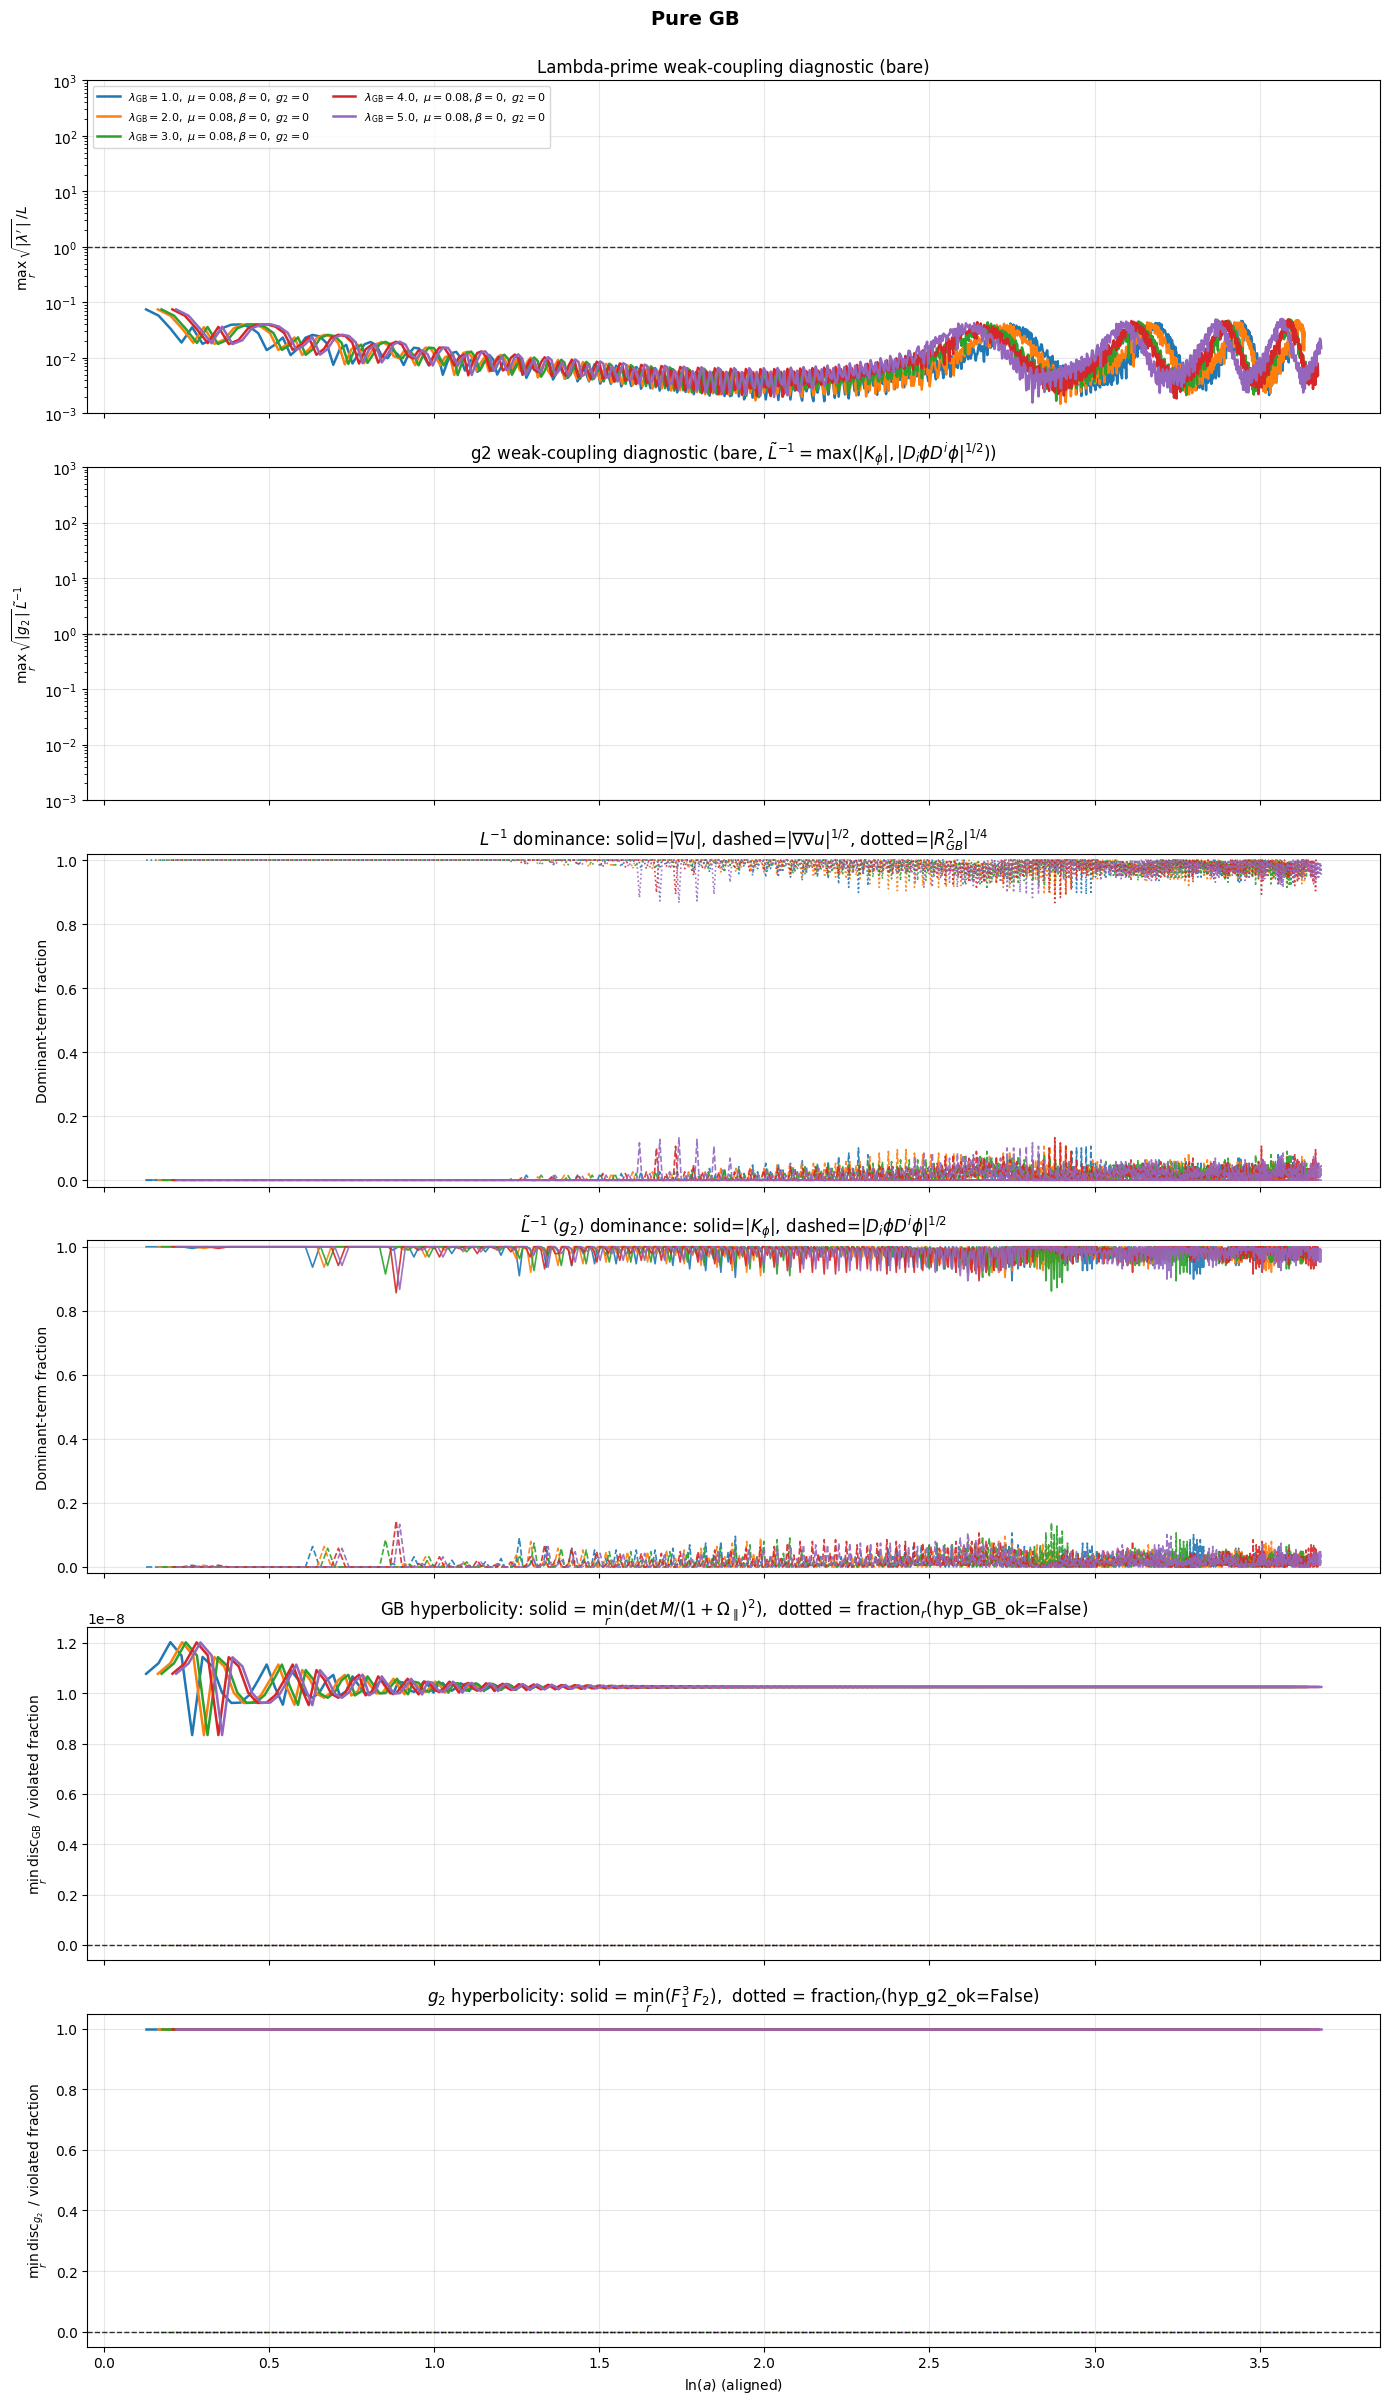

Finite arrays check: True
Dominance consistency check (L^-1): False
Dominance consistency check (L_tilde^-1, g2): False
Sample ranges (first selected run):
  L_inv:       [1.272e-03, 1.948e-01]
  L_tilde_inv: [2.499e-09, 1.265e-01]
  wc_lambda_bare max: 7.465e-02
  wc_g2_bare max:     0.000e+00


In [6]:
# ## 4 — Pure GB: EFT weak-coupling diagnostics and hyperbolicity
# Tracks:
#  - wc_lambda = sqrt(|lambda'|) * L^{-1}
#  - wc_g2     = sqrt(|g2|)      * L_tilde^{-1}   (g2-specific length scale)
#  - L^{-1}       dominance fractions (|grad u|, |hess u|^{1/2}, |R_GB^2|^{1/4})
#  - L_tilde^{-1} dominance fractions (|K_phi|, |D_i phi D^i phi|^{1/2})
#  - GB hyperbolicity: min_r(disc_GB) and violated-fraction (hyp_GB_ok == False)
#  - g2 hyperbolicity: min_r(disc_g2) and violated-fraction (hyp_g2_ok == False)
# Bare (paper/GRChombo) conventions only — the sigmoid- and Sigma-dressed
# "code" versions are not physical comparables and have been removed.

USE_ALIGNED_EFT = True
R_EFT_MAX = 100.0

keys_to_plot = keys_pure_gb

fig, axes = plt.subplots(6, 1, figsize=(14, 24), sharex=True)
cmap = plt.cm.tab10
fig.suptitle("Pure GB", fontsize=14, fontweight="bold", y=1.0)

if len(keys_to_plot) == 0:
    print("No keys_to_plot selected.")
else:
    first_key = keys_to_plot[0]
    eft0 = all_runs[first_key]["eft"]
    r0 = eft0["r"]
    r_mask = (r0 > 0) & (r0 <= R_EFT_MAX)

    for i, key in enumerate(keys_to_plot):
        if key not in all_runs:
            continue
        run = all_runs[key]
        eft = run.get("eft", None)
        if eft is None:
            continue

        lgb, mu, beta, amp, width, g2 = key
        beta_str = rf", \beta={int(beta)}" if beta is not None and beta != 250 else ""
        label = rf"$\lambda_{{\rm GB}}={lgb},\ \mu={mu}{beta_str},\ g_2={g2:g}$"

        x = run["shifted_ln_a"] if USE_ALIGNED_EFT else run["osc"]["ln_a"]
        color = cmap(i % 10)

        wc_lambda_bare_max = np.nanmax(eft["wc_lambda_bare"][:, r_mask], axis=1)
        wc_g2_bare_max = np.nanmax(eft["wc_g2_bare"][:, r_mask], axis=1)

        axes[0].plot(x, wc_lambda_bare_max, color=color, lw=1.8, label=label)
        axes[1].plot(x, wc_g2_bare_max, color=color, lw=1.8, label=label)

        dom = eft["dominant_term_idx"][:, r_mask]
        frac_grad = np.mean(dom == 0, axis=1)
        frac_hess = np.mean(dom == 1, axis=1)
        frac_gb = np.mean(dom == 2, axis=1)

        axes[2].plot(x, frac_grad, color=color, lw=1.2, alpha=0.9)
        axes[2].plot(x, frac_hess, color=color, lw=1.2, ls="--", alpha=0.9)
        axes[2].plot(x, frac_gb, color=color, lw=1.2, ls=":", alpha=0.9)

        # Panel 3: L_tilde^{-1} (g2) dominance — K_phi vs |D_i phi D^i phi|^{1/2}
        if "dominant_g2_term_idx" in eft:
            dom_g2 = eft["dominant_g2_term_idx"][:, r_mask]
            frac_Kphi = np.mean(dom_g2 == 0, axis=1)
            frac_gradphi = np.mean(dom_g2 == 1, axis=1)
            axes[3].plot(x, frac_Kphi, color=color, lw=1.2, alpha=0.9)
            axes[3].plot(x, frac_gradphi, color=color, lw=1.2, ls="--", alpha=0.9)

        # Panel 4: GB hyperbolicity
        if "disc_GB" in eft:
            disc_GB_min = np.nanmin(eft["disc_GB"][:, r_mask], axis=1)
            axes[4].plot(x, disc_GB_min, color=color, lw=1.8, label=label)
            if "hyp_GB_ok" in eft:
                frac_bad_GB = 1.0 - np.mean(eft["hyp_GB_ok"][:, r_mask], axis=1)
                axes[4].plot(x, frac_bad_GB, color=color, lw=1.0, ls=":", alpha=0.7)

        # Panel 5: g2 hyperbolicity
        if "disc_g2" in eft:
            disc_g2_min = np.nanmin(eft["disc_g2"][:, r_mask], axis=1)
            axes[5].plot(x, disc_g2_min, color=color, lw=1.8, label=label)
            if "hyp_g2_ok" in eft:
                frac_bad_g2 = 1.0 - np.mean(eft["hyp_g2_ok"][:, r_mask], axis=1)
                axes[5].plot(x, frac_bad_g2, color=color, lw=1.0, ls=":", alpha=0.7)

    axes[0].axhline(1.0, color="k", lw=1.0, ls="--", alpha=0.8)
    axes[1].axhline(1.0, color="k", lw=1.0, ls="--", alpha=0.8)
    axes[4].axhline(0.0, color="k", lw=1.0, ls="--", alpha=0.8)
    axes[5].axhline(0.0, color="k", lw=1.0, ls="--", alpha=0.8)

    axes[0].set_ylabel(r"$\max_r\,\sqrt{|\lambda'|}\,/L$")
    axes[0].set_title("Lambda-prime weak-coupling diagnostic (bare)")
    axes[0].set_yscale("log")
    axes[0].set_ylim(1e-3, 1e3)
    axes[0].grid(True, alpha=0.3)

    axes[1].set_ylabel(r"$\max_r\,\sqrt{|g_2|}\,\tilde{L}^{-1}$")
    axes[1].set_title(r"g2 weak-coupling diagnostic (bare, $\tilde{L}^{-1}=\max(|K_\phi|,|D_i\phi D^i\phi|^{1/2})$)")
    axes[1].set_yscale("log")
    axes[1].set_ylim(1e-3, 1e3)
    axes[1].grid(True, alpha=0.3)

    axes[2].set_ylabel("Dominant-term fraction")
    axes[2].set_ylim(-0.02, 1.02)
    axes[2].set_title(r"$L^{-1}$ dominance: solid=$|\nabla u|$, dashed=$|\nabla\nabla u|^{1/2}$, dotted=$|R_{GB}^2|^{1/4}$")
    axes[2].grid(True, alpha=0.3)

    axes[3].set_ylabel("Dominant-term fraction")
    axes[3].set_ylim(-0.02, 1.02)
    axes[3].set_title(r"$\tilde{L}^{-1}$ ($g_2$) dominance: solid=$|K_\phi|$, dashed=$|D_i\phi D^i\phi|^{1/2}$")
    axes[3].grid(True, alpha=0.3)

    axes[4].set_ylabel(r"$\min_r\,\mathrm{disc}_{\rm GB}$ / violated fraction")
    axes[4].set_title(r"GB hyperbolicity: solid = $\min_r(\det M / (1+\Omega_{\parallel})^2)$,  dotted = fraction$_r$(hyp_GB_ok=False)")
    #axes[4].set_yscale("symlog", linthresh=1e-3)
    axes[4].grid(True, alpha=0.3)

    axes[5].set_ylabel(r"$\min_r\,\mathrm{disc}_{g_2}$ / violated fraction")
    axes[5].set_title(r"$g_2$ hyperbolicity: solid = $\min_r(F_1^{3} F_2)$,  dotted = fraction$_r$(hyp_g2_ok=False)")
    #axes[5].set_yscale("symlog", linthresh=1e-3)
    axes[5].grid(True, alpha=0.3)

    axes[5].set_xlabel(r"$\ln(a)$" + (" (aligned)" if USE_ALIGNED_EFT else ""))
    axes[0].legend(fontsize=8, ncol=2, loc="upper left")

    fig.tight_layout()
    plt.show()

    # --- sanity checks on the first selected run ---
    dcheck = all_runs[first_key]["eft"]
    finite_ok = (
        np.isfinite(dcheck["L_inv"]).all()
        and np.isfinite(dcheck["wc_lambda_bare"]).all()
        and np.isfinite(dcheck["wc_g2_bare"]).all()
    )
    print(f"Finite arrays check: {finite_ok}")

    terms = np.stack([
        dcheck["term_grad_u"],
        dcheck["term_hess_u_sqrt"],
        dcheck["term_gb_quarter"],
    ], axis=0)
    dom_from_terms = np.argmax(terms, axis=0)
    dom_match = np.array_equal(dom_from_terms, dcheck["dominant_term_idx"])
    print(f"Dominance consistency check (L^-1): {dom_match}")

    if "dominant_g2_term_idx" in dcheck:
        terms_g2 = np.stack([dcheck["K_phi"], dcheck["grad_phi_spatial"]], axis=0)
        dom_g2_from_terms = np.argmax(terms_g2, axis=0)
        dom_g2_match = np.array_equal(dom_g2_from_terms, dcheck["dominant_g2_term_idx"])
        print(f"Dominance consistency check (L_tilde^-1, g2): {dom_g2_match}")

    print("Sample ranges (first selected run):")
    print(f"  L_inv:       [{np.nanmin(dcheck['L_inv']):.3e}, {np.nanmax(dcheck['L_inv']):.3e}]")
    print(f"  L_tilde_inv: [{np.nanmin(dcheck.get('L_tilde_inv', [np.nan])):.3e}, {np.nanmax(dcheck.get('L_tilde_inv', [np.nan])):.3e}]")
    print(f"  wc_lambda_bare max: {np.nanmax(dcheck['wc_lambda_bare']):.3e}")
    print(f"  wc_g2_bare max:     {np.nanmax(dcheck['wc_g2_bare']):.3e}")


## 5 — Pure GB: rho_c, compactness, WCC, and hyperbolicity vs ln(a)

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 

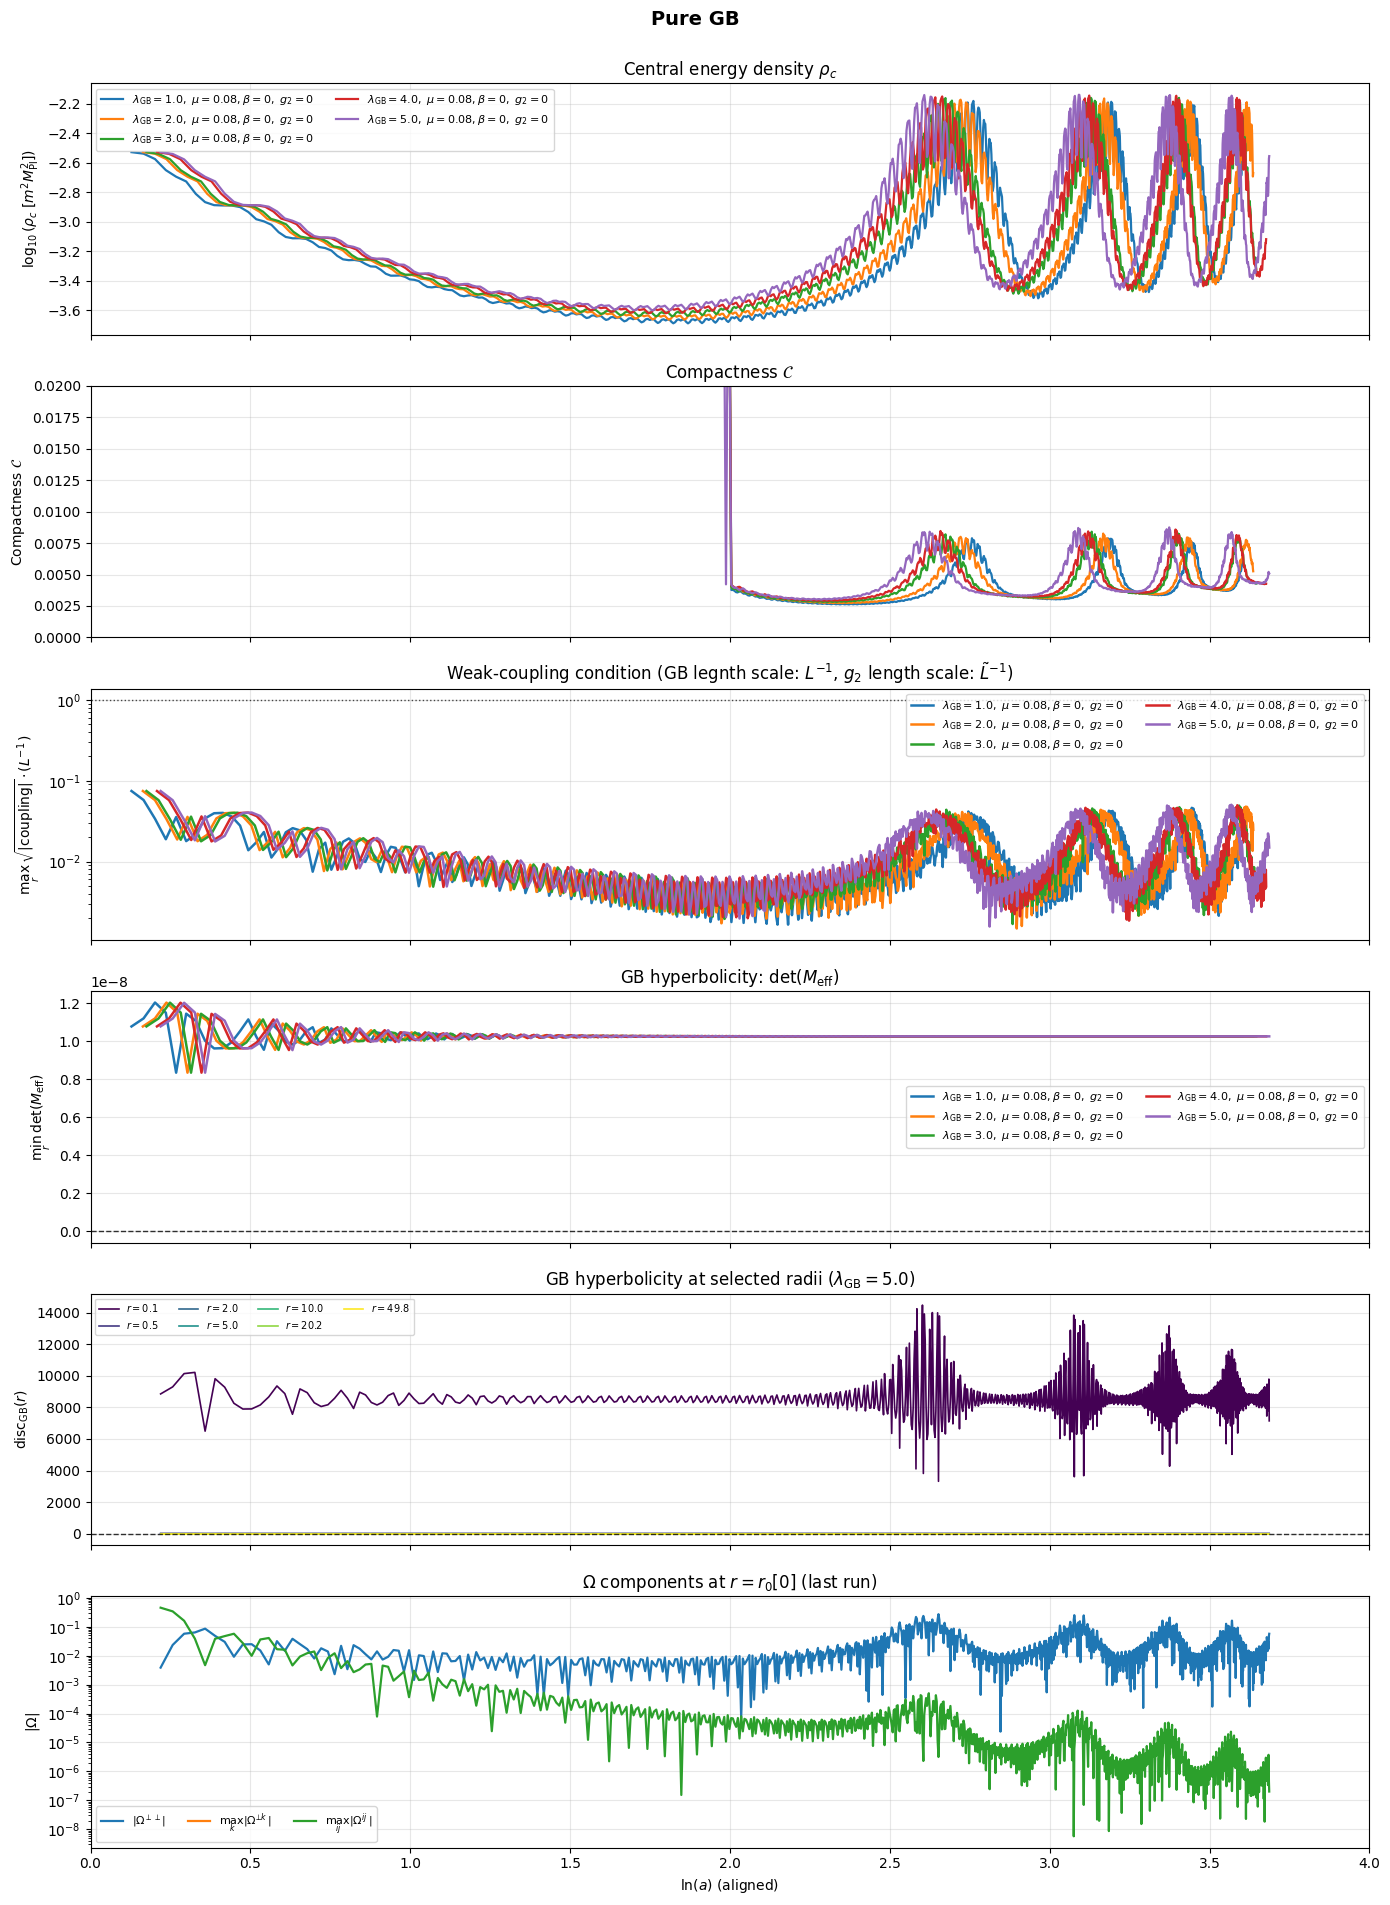

In [7]:
# ## 5 — Pure GB: rho_c, compactness, WCC and hyperbolicity vs ln(a)
# Four stacked panels sharing x-axis:
#   panel 0 : log10(rho_c)
#   panel 1 : compactness C
#   panel 2 : weak-coupling condition max_r(sqrt(|lambda'|)/L)  (and sqrt(|g2|)/L if nonzero)
#   panel 3 : g2 hyperbolicity  min_r(disc_g2)  and violated-fraction (hyp_g2_ok == False)

USE_ALIGNED_COMBO = True
R_WCC_MAX = 100.0

keys_to_plot = keys_pure_gb

fig, axes = plt.subplots(6, 1, figsize=(14, 19), sharex=True)
cmap = plt.cm.tab10
fig.suptitle("Pure GB", fontsize=14, fontweight="bold", y=1.0)

if len(keys_to_plot) == 0:
    print("No keys_to_plot selected.")
else:
    first_key = keys_to_plot[0]
    eft0 = all_runs[first_key].get("eft", None)
    r0 = eft0["r"] if eft0 is not None else None
    r_mask = (r0 > 0) & (r0 <= R_WCC_MAX) if r0 is not None else None

    any_g2_nonzero = False
    for i, key in enumerate(keys_to_plot):
        run = all_runs[key]
        osc = run["osc"]
        eft = run.get("eft", None)

        lgb, mu, beta, amp, width, g2 = key
        beta_str = rf", \beta={int(beta)}" if beta is not None and beta != 250 else ""
        label = rf"$\lambda_{{\rm GB}}={lgb},\ \mu={mu}{beta_str},\ g_2={g2:g}$"
        color = cmap(i % 10)

        x = run["shifted_ln_a"] if USE_ALIGNED_COMBO else osc["ln_a"]

        # Panel 1: log10(rho_c)
        rho_c = osc["rho_c"]
        pos = rho_c > 0
        y_rho = np.full_like(rho_c, np.nan, dtype=float)
        y_rho[pos] = np.log10(rho_c[pos])
        axes[0].plot(x, y_rho, color=color, lw=1.6, label=label)

        # Panel 2: compactness
        axes[1].plot(x, osc["C"], color=color, lw=1.6, label=label)

        # Panel 3: weak-coupling conditions
        if eft is not None:
            wc_lam = np.nanmax(eft["wc_lambda_bare"][:, r_mask], axis=1)
            axes[2].plot(x, wc_lam, color=color, lw=1.8, label=label)
            if g2 != 0:
                wc_g2 = np.nanmax(eft["wc_g2_bare"][:, r_mask], axis=1)
                axes[2].plot(x, wc_g2, color=color, lw=1.2, ls="--", alpha=0.85)
                any_g2_nonzero = True

         # Panel 3: GB hyperbolicity (numerator = det_M)
        if eft is not None and "disc_GB" in eft:
            disc_GB_min = np.nanmin(eft["disc_GB"][:, r_mask], axis=1)
            axes[3].plot(x, disc_GB_min, color=color, lw=1.8, label=label)

    # Panel 4: disc_GB at selected radii vs time (only for last run in loop)
    last_run = all_runs[keys_to_plot[-1]]
    last_eft = last_run.get("eft", None)
    if last_eft is not None and "disc_GB" in last_eft:
        last_x = last_run["shifted_ln_a"] if USE_ALIGNED_COMBO else last_run["osc"]["ln_a"]
        r_sample = [0.1, 0.5, 2.0, 5.0, 10.0, 20.0, 50.0]
        lgb_last = keys_to_plot[-1][0]
        cmap_r = plt.cm.viridis
        for j, r_val in enumerate(r_sample):
            r_idx = np.argmin(np.abs(r0 - r_val))
            disc_at_r = last_eft["disc_GB"][:, r_idx]
            c_r = cmap_r(j / max(len(r_sample) - 1, 1))
            axes[4].plot(last_x, disc_at_r, color=c_r, lw=1.2,
                         label=rf"$r={r0[r_idx]:.1f}$")

    # Panel 5: Omega components at center (r = r0[0]) for last run -- diagnostic
    if last_eft is not None and all(k in last_eft for k in ("Omega_pp", "Omega_perp_U", "Omega_UU")):
        i_center = 0
        Omega_pp_c     = np.abs(last_eft["Omega_pp"][:, i_center])
        Omega_perp_max = np.max(np.abs(last_eft["Omega_perp_U"][:, i_center, :]), axis=-1)
        Omega_UU_max   = np.max(np.abs(last_eft["Omega_UU"][:, i_center, :, :]), axis=(-2, -1))
        axes[5].plot(last_x, Omega_pp_c,     lw=1.6, label=r"$|\Omega^{\perp\perp}|$")
        axes[5].plot(last_x, Omega_perp_max, lw=1.6, label=r"$\max_k|\Omega^{\perp k}|$")
        axes[5].plot(last_x, Omega_UU_max,   lw=1.6, label=r"$\max_{ij}|\Omega^{ij}|$")

    axes[0].set_ylabel(r"$\log_{10}(\rho_c \; [m^2 M_{\rm Pl}^2])$")
    axes[0].set_title(r"Central energy density $\rho_c$")
    axes[0].grid(True, alpha=0.3)
    axes[0].set_xlim(0, 4)

    axes[1].set_ylabel(r"Compactness $\mathcal{C}$")
    axes[1].set_title(r"Compactness $\mathcal{C}$")
    axes[1].grid(True, alpha=0.3)
    axes[1].set_ylim(0, 0.02)

    axes[2].axhline(1.0, color="k", lw=1.0, ls=":", alpha=0.7)
    axes[2].set_ylabel(r"$\max_r\,\sqrt{|\mathrm{coupling}|}\,\cdot\,(L^{-1})$")
    wcc_title = r"Weak-coupling condition (GB legnth scale: $L^{-1}$, $g_2$ length scale: $\tilde{L}^{-1}$)"
    axes[2].set_title(wcc_title)
    axes[2].set_yscale("log")
    axes[2].grid(True, alpha=0.3)

    axes[3].axhline(0.0, color="k", lw=1.0, ls="--", alpha=0.8)
    axes[3].set_ylabel(r"$\min_r\,\det(M_{\rm eff})$")
    axes[3].set_title(r"GB hyperbolicity: $\det(M_{\rm eff})$")
    axes[3].grid(True, alpha=0.3)

    axes[4].axhline(0.0, color="k", lw=1.0, ls="--", alpha=0.8)
    lgb_last = keys_to_plot[-1][0]
    axes[4].set_ylabel(r"$\mathrm{disc}_{\rm GB}(r)$")
    axes[4].set_title(rf"GB hyperbolicity at selected radii ($\lambda_{{\rm GB}}={lgb_last}$)")
    axes[4].grid(True, alpha=0.3)
    axes[4].legend(fontsize=7, ncol=4, loc="best")

    axes[5].set_yscale("log")
    axes[5].set_ylabel(r"$|\Omega|$")
    axes[5].set_title(r"$\Omega$ components at $r = r_0[0]$ (last run)")
    axes[5].grid(True, alpha=0.3)
    axes[5].legend(fontsize=8, ncol=3, loc="best")

    axes[5].set_xlabel(r"$\ln(a)$" + (" (aligned)" if USE_ALIGNED_COMBO else ""))
    axes[0].legend(fontsize=8, ncol=2, loc="best")
    axes[2].legend(fontsize=8, ncol=2, loc="best")
    axes[3].legend(fontsize=8, ncol=2, loc="best")

    i_center = 0  # or np.argmin(np.abs(r0))
    dom_center = eft["dominant_term_idx"][:, i_center]      # 0, 1, or 2
    dom_g2_center = eft["dominant_g2_term_idx"][:, i_center] # 0 or 1
    
    print(dom_g2_center)

    fig.tight_layout()
    plt.show()

## 6 — Pure g2: EFT weak-coupling and hyperbolicity

In [ ]:
# ## 6 — Pure g2: EFT weak-coupling diagnostics and hyperbolicity
# Tracks:
#  - wc_lambda = sqrt(|lambda'|) * L^{-1}
#  - wc_g2     = sqrt(|g2|)      * L_tilde^{-1}   (g2-specific length scale)
#  - L^{-1}       dominance fractions (|grad u|, |hess u|^{1/2}, |R_GB^2|^{1/4})
#  - L_tilde^{-1} dominance fractions (|K_phi|, |D_i phi D^i phi|^{1/2})
#  - GB hyperbolicity: min_r(disc_GB) and violated-fraction (hyp_GB_ok == False)
#  - g2 hyperbolicity: min_r(disc_g2) and violated-fraction (hyp_g2_ok == False)
# Bare (paper/GRChombo) conventions only — the sigmoid- and Sigma-dressed
# "code" versions are not physical comparables and have been removed.

USE_ALIGNED_EFT = True
R_EFT_MAX = 100.0

keys_to_plot = keys_pure_g2

fig, axes = plt.subplots(6, 1, figsize=(14, 24), sharex=True)
cmap = plt.cm.tab10
fig.suptitle("Pure g2", fontsize=14, fontweight="bold", y=1.0)

if len(keys_to_plot) == 0:
    print("No keys_to_plot selected.")
else:
    first_key = keys_to_plot[0]
    eft0 = all_runs[first_key]["eft"]
    r0 = eft0["r"]
    r_mask = (r0 > 0) & (r0 <= R_EFT_MAX)

    for i, key in enumerate(keys_to_plot):
        if key not in all_runs:
            continue
        run = all_runs[key]
        eft = run.get("eft", None)
        if eft is None:
            continue

        lgb, mu, beta, amp, width, g2 = key
        beta_str = rf", \beta={int(beta)}" if beta is not None and beta != 250 else ""
        label = rf"$\lambda_{{\rm GB}}={lgb},\ \mu={mu}{beta_str},\ g_2={g2:g}$"

        x = run["shifted_ln_a"] if USE_ALIGNED_EFT else run["osc"]["ln_a"]
        color = cmap(i % 10)

        wc_lambda_bare_max = np.nanmax(eft["wc_lambda_bare"][:, r_mask], axis=1)
        wc_g2_bare_max = np.nanmax(eft["wc_g2_bare"][:, r_mask], axis=1)

        axes[0].plot(x, wc_lambda_bare_max, color=color, lw=1.8, label=label)
        axes[1].plot(x, wc_g2_bare_max, color=color, lw=1.8, label=label)

        dom = eft["dominant_term_idx"][:, r_mask]
        frac_grad = np.mean(dom == 0, axis=1)
        frac_hess = np.mean(dom == 1, axis=1)
        frac_gb = np.mean(dom == 2, axis=1)

        axes[2].plot(x, frac_grad, color=color, lw=1.2, alpha=0.9)
        axes[2].plot(x, frac_hess, color=color, lw=1.2, ls="--", alpha=0.9)
        axes[2].plot(x, frac_gb, color=color, lw=1.2, ls=":", alpha=0.9)

        # Panel 3: L_tilde^{-1} (g2) dominance — K_phi vs |D_i phi D^i phi|^{1/2}
        if "dominant_g2_term_idx" in eft:
            dom_g2 = eft["dominant_g2_term_idx"][:, r_mask]
            frac_Kphi = np.mean(dom_g2 == 0, axis=1)
            frac_gradphi = np.mean(dom_g2 == 1, axis=1)
            axes[3].plot(x, frac_Kphi, color=color, lw=1.2, alpha=0.9)
            axes[3].plot(x, frac_gradphi, color=color, lw=1.2, ls="--", alpha=0.9)

        # Panel 4: GB hyperbolicity
        if "disc_GB" in eft:
            disc_GB_min = np.nanmin(eft["disc_GB"][:, r_mask], axis=1)
            axes[4].plot(x, disc_GB_min, color=color, lw=1.8, label=label)
            if "hyp_GB_ok" in eft:
                frac_bad_GB = 1.0 - np.mean(eft["hyp_GB_ok"][:, r_mask], axis=1)
                axes[4].plot(x, frac_bad_GB, color=color, lw=1.0, ls=":", alpha=0.7)

        # Panel 5: g2 hyperbolicity
        if "disc_g2" in eft:
            disc_g2_min = np.nanmin(eft["disc_g2"][:, r_mask], axis=1)
            axes[5].plot(x, disc_g2_min, color=color, lw=1.8, label=label)
            if "hyp_g2_ok" in eft:
                frac_bad_g2 = 1.0 - np.mean(eft["hyp_g2_ok"][:, r_mask], axis=1)
                axes[5].plot(x, frac_bad_g2, color=color, lw=1.0, ls=":", alpha=0.7)

    axes[0].axhline(1.0, color="k", lw=1.0, ls="--", alpha=0.8)
    axes[1].axhline(1.0, color="k", lw=1.0, ls="--", alpha=0.8)
    axes[4].axhline(0.0, color="k", lw=1.0, ls="--", alpha=0.8)
    axes[5].axhline(0.0, color="k", lw=1.0, ls="--", alpha=0.8)

    axes[0].set_ylabel(r"$\max_r\,\sqrt{|\lambda'|}\,/L$")
    axes[0].set_title("Lambda-prime weak-coupling diagnostic (bare)")
    axes[0].set_yscale("log")
    axes[0].set_ylim(1e-3, 1e3)
    axes[0].grid(True, alpha=0.3)

    axes[1].set_ylabel(r"$\max_r\,\sqrt{|g_2|}\,\tilde{L}^{-1}$")
    axes[1].set_title(r"g2 weak-coupling diagnostic (bare, $\tilde{L}^{-1}=\max(|K_\phi|,|D_i\phi D^i\phi|^{1/2})$)")
    axes[1].set_yscale("log")
    axes[1].set_ylim(1e-3, 1e3)
    axes[1].grid(True, alpha=0.3)

    axes[2].set_ylabel("Dominant-term fraction")
    axes[2].set_ylim(-0.02, 1.02)
    axes[2].set_title(r"$L^{-1}$ dominance: solid=$|\nabla u|$, dashed=$|\nabla\nabla u|^{1/2}$, dotted=$|R_{GB}^2|^{1/4}$")
    axes[2].grid(True, alpha=0.3)

    axes[3].set_ylabel("Dominant-term fraction")
    axes[3].set_ylim(-0.02, 1.02)
    axes[3].set_title(r"$\tilde{L}^{-1}$ ($g_2$) dominance: solid=$|K_\phi|$, dashed=$|D_i\phi D^i\phi|^{1/2}$")
    axes[3].grid(True, alpha=0.3)

    axes[4].set_ylabel(r"$\min_r\,\mathrm{disc}_{\rm GB}$ / violated fraction")
    axes[4].set_title(r"GB hyperbolicity: solid = $\min_r(\det M / (1+\Omega_{\parallel})^2)$,  dotted = fraction$_r$(hyp_GB_ok=False)")
    #axes[4].set_yscale("symlog", linthresh=1e-3)
    axes[4].grid(True, alpha=0.3)

    axes[5].set_ylabel(r"$\min_r\,\mathrm{disc}_{g_2}$ / violated fraction")
    axes[5].set_title(r"$g_2$ hyperbolicity: solid = $\min_r(F_1^{3} F_2)$,  dotted = fraction$_r$(hyp_g2_ok=False)")
    #axes[5].set_yscale("symlog", linthresh=1e-3)
    axes[5].grid(True, alpha=0.3)

    axes[5].set_xlabel(r"$\ln(a)$" + (" (aligned)" if USE_ALIGNED_EFT else ""))
    axes[0].legend(fontsize=8, ncol=2, loc="upper left")

    fig.tight_layout()
    plt.show()

    # --- sanity checks on the first selected run ---
    dcheck = all_runs[first_key]["eft"]
    finite_ok = (
        np.isfinite(dcheck["L_inv"]).all()
        and np.isfinite(dcheck["wc_lambda_bare"]).all()
        and np.isfinite(dcheck["wc_g2_bare"]).all()
    )
    print(f"Finite arrays check: {finite_ok}")

    terms = np.stack([
        dcheck["term_grad_u"],
        dcheck["term_hess_u_sqrt"],
        dcheck["term_gb_quarter"],
    ], axis=0)
    dom_from_terms = np.argmax(terms, axis=0)
    dom_match = np.array_equal(dom_from_terms, dcheck["dominant_term_idx"])
    print(f"Dominance consistency check (L^-1): {dom_match}")

    if "dominant_g2_term_idx" in dcheck:
        terms_g2 = np.stack([dcheck["K_phi"], dcheck["grad_phi_spatial"]], axis=0)
        dom_g2_from_terms = np.argmax(terms_g2, axis=0)
        dom_g2_match = np.array_equal(dom_g2_from_terms, dcheck["dominant_g2_term_idx"])
        print(f"Dominance consistency check (L_tilde^-1, g2): {dom_g2_match}")

    print("Sample ranges (first selected run):")
    print(f"  L_inv:       [{np.nanmin(dcheck['L_inv']):.3e}, {np.nanmax(dcheck['L_inv']):.3e}]")
    print(f"  L_tilde_inv: [{np.nanmin(dcheck.get('L_tilde_inv', [np.nan])):.3e}, {np.nanmax(dcheck.get('L_tilde_inv', [np.nan])):.3e}]")
    print(f"  wc_lambda_bare max: {np.nanmax(dcheck['wc_lambda_bare']):.3e}")
    print(f"  wc_g2_bare max:     {np.nanmax(dcheck['wc_g2_bare']):.3e}")


## 7 — Pure g2: rho_c, compactness, WCC, and hyperbolicity vs ln(a)

In [ ]:
# ## 7 — Pure g2: rho_c, compactness, WCC and hyperbolicity vs ln(a)
# Four stacked panels sharing x-axis:
#   panel 0 : log10(rho_c)
#   panel 1 : compactness C
#   panel 2 : weak-coupling condition max_r(sqrt(|lambda'|)/L)  (and sqrt(|g2|)/L if nonzero)
#   panel 3 : g2 hyperbolicity  min_r(disc_g2)  and violated-fraction (hyp_g2_ok == False)

USE_ALIGNED_COMBO = True
R_WCC_MAX = 100.0

keys_to_plot = keys_pure_g2

fig, axes = plt.subplots(4, 1, figsize=(14, 16), sharex=True)
cmap = plt.cm.tab10
fig.suptitle("Pure g2", fontsize=14, fontweight="bold", y=1.0)

if len(keys_to_plot) == 0:
    print("No keys_to_plot selected.")
else:
    first_key = keys_to_plot[0]
    eft0 = all_runs[first_key].get("eft", None)
    r0 = eft0["r"] if eft0 is not None else None
    r_mask = (r0 > 0) & (r0 <= R_WCC_MAX) if r0 is not None else None

    any_g2_nonzero = False
    for i, key in enumerate(keys_to_plot):
        run = all_runs[key]
        osc = run["osc"]
        eft = run.get("eft", None)

        lgb, mu, beta, amp, width, g2 = key
        beta_str = rf", \beta={int(beta)}" if beta is not None and beta != 250 else ""
        label = rf"$\lambda_{{\rm GB}}={lgb},\ \mu={mu}{beta_str},\ g_2={g2:g}$"
        color = cmap(i % 10)

        x = run["shifted_ln_a"] if USE_ALIGNED_COMBO else osc["ln_a"]

        # Panel 1: log10(rho_c)
        rho_c = osc["rho_c"]
        pos = rho_c > 0
        y_rho = np.full_like(rho_c, np.nan, dtype=float)
        y_rho[pos] = np.log10(rho_c[pos])
        axes[0].plot(x, y_rho, color=color, lw=1.6, label=label)

        # Panel 2: compactness
        axes[1].plot(x, osc["C"], color=color, lw=1.6, label=label)

        # Panel 3: weak-coupling conditions
        if eft is not None:
            wc_lam = np.nanmax(eft["wc_lambda_bare"][:, r_mask], axis=1)
            axes[2].plot(x, wc_lam, color=color, lw=1.8, label=label)
            if g2 != 0:
                wc_g2 = np.nanmax(eft["wc_g2_bare"][:, r_mask], axis=1)
                axes[2].plot(x, wc_g2, color=color, lw=1.2, ls="--", alpha=0.85)
                any_g2_nonzero = True

        # Panel 4: g2 hyperbolicity
        if eft is not None and "disc_g2" in eft:
            disc_g2_min = np.nanmin(eft["disc_g2"][:, r_mask], axis=1)
            axes[3].plot(x, disc_g2_min, color=color, lw=1.8, label=label)
            #if "hyp_g2_ok" in eft:
            #    frac_bad_g2 = 1.0 - np.mean(eft["hyp_g2_ok"][:, r_mask], axis=1)
            #    axes[3].plot(x, frac_bad_g2, color=color, lw=1.0, ls=":", alpha=0.7)

    axes[0].set_ylabel(r"$\log_{10}(\rho_c \; [m^2 M_{\rm Pl}^2])$")
    axes[0].set_title(r"Central energy density $\rho_c$")
    axes[0].grid(True, alpha=0.3)
    axes[0].set_xlim(0, 4)

    axes[1].set_ylabel(r"Compactness $\mathcal{C}$")
    axes[1].set_title(r"Compactness $\mathcal{C}$")
    axes[1].grid(True, alpha=0.3)
    axes[1].set_ylim(0, 0.02)

    axes[2].axhline(1.0, color="k", lw=1.0, ls=":", alpha=0.7)
    axes[2].set_ylabel(r"$\max_r\,\sqrt{|\mathrm{coupling}|}\,\cdot\,(L^{-1})$")
    wcc_title = r"Weak-coupling condition (GB legnth scale: $L^{-1}$, $g_2$ length scale: $\tilde{L}^{-1}$)"
    axes[2].set_title(wcc_title)
    axes[2].set_yscale("log")
    axes[2].grid(True, alpha=0.3)

    axes[3].axhline(0.0, color="k", lw=1.0, ls="--", alpha=0.8)
    axes[3].set_ylabel(r"det(effective metric)/det(metric) ")
    axes[3].set_title(r"$g_2$ hyperbolicity")
    #axes[3].set_yscale("symlog", linthresh=1e-3)
    axes[3].grid(True, alpha=0.3)

    axes[3].set_xlabel(r"$\ln(a)$" + (" (aligned)" if USE_ALIGNED_COMBO else ""))
    axes[0].legend(fontsize=8, ncol=2, loc="best")
    axes[2].legend(fontsize=8, ncol=2, loc="best")
    axes[3].legend(fontsize=8, ncol=2, loc="best")

    i_center = 0  # or np.argmin(np.abs(r0))
    dom_center = eft["dominant_term_idx"][:, i_center]      # 0, 1, or 2
    dom_g2_center = eft["dominant_g2_term_idx"][:, i_center] # 0 or 1
    
    print(dom_g2_center)

    fig.tight_layout()
    plt.show()

## 8 — Mixed GB + g2: EFT weak-coupling and hyperbolicity

In [ ]:
# ## 8 — Mixed GB + g2: EFT weak-coupling diagnostics and hyperbolicity
# Tracks:
#  - wc_lambda = sqrt(|lambda'|) * L^{-1}
#  - wc_g2     = sqrt(|g2|)      * L_tilde^{-1}   (g2-specific length scale)
#  - L^{-1}       dominance fractions (|grad u|, |hess u|^{1/2}, |R_GB^2|^{1/4})
#  - L_tilde^{-1} dominance fractions (|K_phi|, |D_i phi D^i phi|^{1/2})
#  - GB hyperbolicity: min_r(disc_GB) and violated-fraction (hyp_GB_ok == False)
#  - g2 hyperbolicity: min_r(disc_g2) and violated-fraction (hyp_g2_ok == False)
# Bare (paper/GRChombo) conventions only — the sigmoid- and Sigma-dressed
# "code" versions are not physical comparables and have been removed.

USE_ALIGNED_EFT = True
R_EFT_MAX = 100.0

keys_to_plot = keys_mixed

fig, axes = plt.subplots(6, 1, figsize=(14, 24), sharex=True)
cmap = plt.cm.tab10
fig.suptitle("Mixed GB + g2", fontsize=14, fontweight="bold", y=1.0)

if len(keys_to_plot) == 0:
    print("No keys_to_plot selected.")
else:
    first_key = keys_to_plot[0]
    eft0 = all_runs[first_key]["eft"]
    r0 = eft0["r"]
    r_mask = (r0 > 0) & (r0 <= R_EFT_MAX)

    for i, key in enumerate(keys_to_plot):
        if key not in all_runs:
            continue
        run = all_runs[key]
        eft = run.get("eft", None)
        if eft is None:
            continue

        lgb, mu, beta, amp, width, g2 = key
        beta_str = rf", \beta={int(beta)}" if beta is not None and beta != 250 else ""
        label = rf"$\lambda_{{\rm GB}}={lgb},\ \mu={mu}{beta_str},\ g_2={g2:g}$"

        x = run["shifted_ln_a"] if USE_ALIGNED_EFT else run["osc"]["ln_a"]
        color = cmap(i % 10)

        wc_lambda_bare_max = np.nanmax(eft["wc_lambda_bare"][:, r_mask], axis=1)
        wc_g2_bare_max = np.nanmax(eft["wc_g2_bare"][:, r_mask], axis=1)

        axes[0].plot(x, wc_lambda_bare_max, color=color, lw=1.8, label=label)
        axes[1].plot(x, wc_g2_bare_max, color=color, lw=1.8, label=label)

        dom = eft["dominant_term_idx"][:, r_mask]
        frac_grad = np.mean(dom == 0, axis=1)
        frac_hess = np.mean(dom == 1, axis=1)
        frac_gb = np.mean(dom == 2, axis=1)

        axes[2].plot(x, frac_grad, color=color, lw=1.2, alpha=0.9)
        axes[2].plot(x, frac_hess, color=color, lw=1.2, ls="--", alpha=0.9)
        axes[2].plot(x, frac_gb, color=color, lw=1.2, ls=":", alpha=0.9)

        # Panel 3: L_tilde^{-1} (g2) dominance — K_phi vs |D_i phi D^i phi|^{1/2}
        if "dominant_g2_term_idx" in eft:
            dom_g2 = eft["dominant_g2_term_idx"][:, r_mask]
            frac_Kphi = np.mean(dom_g2 == 0, axis=1)
            frac_gradphi = np.mean(dom_g2 == 1, axis=1)
            axes[3].plot(x, frac_Kphi, color=color, lw=1.2, alpha=0.9)
            axes[3].plot(x, frac_gradphi, color=color, lw=1.2, ls="--", alpha=0.9)

        # Panel 4: GB hyperbolicity
        if "disc_GB" in eft:
            disc_GB_min = np.nanmin(eft["disc_GB"][:, r_mask], axis=1)
            axes[4].plot(x, disc_GB_min, color=color, lw=1.8, label=label)
            if "hyp_GB_ok" in eft:
                frac_bad_GB = 1.0 - np.mean(eft["hyp_GB_ok"][:, r_mask], axis=1)
                axes[4].plot(x, frac_bad_GB, color=color, lw=1.0, ls=":", alpha=0.7)

        # Panel 5: g2 hyperbolicity
        if "disc_g2" in eft:
            disc_g2_min = np.nanmin(eft["disc_g2"][:, r_mask], axis=1)
            axes[5].plot(x, disc_g2_min, color=color, lw=1.8, label=label)
            if "hyp_g2_ok" in eft:
                frac_bad_g2 = 1.0 - np.mean(eft["hyp_g2_ok"][:, r_mask], axis=1)
                axes[5].plot(x, frac_bad_g2, color=color, lw=1.0, ls=":", alpha=0.7)

    axes[0].axhline(1.0, color="k", lw=1.0, ls="--", alpha=0.8)
    axes[1].axhline(1.0, color="k", lw=1.0, ls="--", alpha=0.8)
    axes[4].axhline(0.0, color="k", lw=1.0, ls="--", alpha=0.8)
    axes[5].axhline(0.0, color="k", lw=1.0, ls="--", alpha=0.8)

    axes[0].set_ylabel(r"$\max_r\,\sqrt{|\lambda'|}\,/L$")
    axes[0].set_title("Lambda-prime weak-coupling diagnostic (bare)")
    axes[0].set_yscale("log")
    axes[0].set_ylim(1e-3, 1e3)
    axes[0].grid(True, alpha=0.3)

    axes[1].set_ylabel(r"$\max_r\,\sqrt{|g_2|}\,\tilde{L}^{-1}$")
    axes[1].set_title(r"g2 weak-coupling diagnostic (bare, $\tilde{L}^{-1}=\max(|K_\phi|,|D_i\phi D^i\phi|^{1/2})$)")
    axes[1].set_yscale("log")
    axes[1].set_ylim(1e-3, 1e3)
    axes[1].grid(True, alpha=0.3)

    axes[2].set_ylabel("Dominant-term fraction")
    axes[2].set_ylim(-0.02, 1.02)
    axes[2].set_title(r"$L^{-1}$ dominance: solid=$|\nabla u|$, dashed=$|\nabla\nabla u|^{1/2}$, dotted=$|R_{GB}^2|^{1/4}$")
    axes[2].grid(True, alpha=0.3)

    axes[3].set_ylabel("Dominant-term fraction")
    axes[3].set_ylim(-0.02, 1.02)
    axes[3].set_title(r"$\tilde{L}^{-1}$ ($g_2$) dominance: solid=$|K_\phi|$, dashed=$|D_i\phi D^i\phi|^{1/2}$")
    axes[3].grid(True, alpha=0.3)

    axes[4].set_ylabel(r"$\min_r\,\mathrm{disc}_{\rm GB}$ / violated fraction")
    axes[4].set_title(r"GB hyperbolicity: solid = $\min_r(\det M / (1+\Omega_{\parallel})^2)$,  dotted = fraction$_r$(hyp_GB_ok=False)")
    #axes[4].set_yscale("symlog", linthresh=1e-3)
    axes[4].grid(True, alpha=0.3)

    axes[5].set_ylabel(r"$\min_r\,\mathrm{disc}_{g_2}$ / violated fraction")
    axes[5].set_title(r"$g_2$ hyperbolicity: solid = $\min_r(F_1^{3} F_2)$,  dotted = fraction$_r$(hyp_g2_ok=False)")
    #axes[5].set_yscale("symlog", linthresh=1e-3)
    axes[5].grid(True, alpha=0.3)

    axes[5].set_xlabel(r"$\ln(a)$" + (" (aligned)" if USE_ALIGNED_EFT else ""))
    axes[0].legend(fontsize=8, ncol=2, loc="upper left")

    fig.tight_layout()
    plt.show()

    # --- sanity checks on the first selected run ---
    dcheck = all_runs[first_key]["eft"]
    finite_ok = (
        np.isfinite(dcheck["L_inv"]).all()
        and np.isfinite(dcheck["wc_lambda_bare"]).all()
        and np.isfinite(dcheck["wc_g2_bare"]).all()
    )
    print(f"Finite arrays check: {finite_ok}")

    terms = np.stack([
        dcheck["term_grad_u"],
        dcheck["term_hess_u_sqrt"],
        dcheck["term_gb_quarter"],
    ], axis=0)
    dom_from_terms = np.argmax(terms, axis=0)
    dom_match = np.array_equal(dom_from_terms, dcheck["dominant_term_idx"])
    print(f"Dominance consistency check (L^-1): {dom_match}")

    if "dominant_g2_term_idx" in dcheck:
        terms_g2 = np.stack([dcheck["K_phi"], dcheck["grad_phi_spatial"]], axis=0)
        dom_g2_from_terms = np.argmax(terms_g2, axis=0)
        dom_g2_match = np.array_equal(dom_g2_from_terms, dcheck["dominant_g2_term_idx"])
        print(f"Dominance consistency check (L_tilde^-1, g2): {dom_g2_match}")

    print("Sample ranges (first selected run):")
    print(f"  L_inv:       [{np.nanmin(dcheck['L_inv']):.3e}, {np.nanmax(dcheck['L_inv']):.3e}]")
    print(f"  L_tilde_inv: [{np.nanmin(dcheck.get('L_tilde_inv', [np.nan])):.3e}, {np.nanmax(dcheck.get('L_tilde_inv', [np.nan])):.3e}]")
    print(f"  wc_lambda_bare max: {np.nanmax(dcheck['wc_lambda_bare']):.3e}")
    print(f"  wc_g2_bare max:     {np.nanmax(dcheck['wc_g2_bare']):.3e}")


## 9 — Mixed GB + g2: rho_c, compactness, WCC, and hyperbolicity vs ln(a)

In [ ]:
# ## 9 — Mixed GB + g2: rho_c, compactness, WCC and hyperbolicity vs ln(a)
# Four stacked panels sharing x-axis:
#   panel 0 : log10(rho_c)
#   panel 1 : compactness C
#   panel 2 : weak-coupling condition max_r(sqrt(|lambda'|)/L)  (and sqrt(|g2|)/L if nonzero)
#   panel 3 : g2 hyperbolicity  min_r(disc_g2)  and violated-fraction (hyp_g2_ok == False)

USE_ALIGNED_COMBO = True
R_WCC_MAX = 100.0

keys_to_plot = keys_mixed

fig, axes = plt.subplots(4, 1, figsize=(14, 16), sharex=True)
cmap = plt.cm.tab10
fig.suptitle("Mixed GB + g2", fontsize=14, fontweight="bold", y=1.0)

if len(keys_to_plot) == 0:
    print("No keys_to_plot selected.")
else:
    first_key = keys_to_plot[0]
    eft0 = all_runs[first_key].get("eft", None)
    r0 = eft0["r"] if eft0 is not None else None
    r_mask = (r0 > 0) & (r0 <= R_WCC_MAX) if r0 is not None else None

    any_g2_nonzero = False
    for i, key in enumerate(keys_to_plot):
        run = all_runs[key]
        osc = run["osc"]
        eft = run.get("eft", None)

        lgb, mu, beta, amp, width, g2 = key
        beta_str = rf", \beta={int(beta)}" if beta is not None and beta != 250 else ""
        label = rf"$\lambda_{{\rm GB}}={lgb},\ \mu={mu}{beta_str},\ g_2={g2:g}$"
        color = cmap(i % 10)

        x = run["shifted_ln_a"] if USE_ALIGNED_COMBO else osc["ln_a"]

        # Panel 1: log10(rho_c)
        rho_c = osc["rho_c"]
        pos = rho_c > 0
        y_rho = np.full_like(rho_c, np.nan, dtype=float)
        y_rho[pos] = np.log10(rho_c[pos])
        axes[0].plot(x, y_rho, color=color, lw=1.6, label=label)

        # Panel 2: compactness
        axes[1].plot(x, osc["C"], color=color, lw=1.6, label=label)

        # Panel 3: weak-coupling conditions
        if eft is not None:
            wc_lam = np.nanmax(eft["wc_lambda_bare"][:, r_mask], axis=1)
            axes[2].plot(x, wc_lam, color=color, lw=1.8, label=label)
            if g2 != 0:
                wc_g2 = np.nanmax(eft["wc_g2_bare"][:, r_mask], axis=1)
                axes[2].plot(x, wc_g2, color=color, lw=1.2, ls="--", alpha=0.85)
                any_g2_nonzero = True

        # Panel 4: g2 hyperbolicity
        if eft is not None and "disc_g2" in eft:
            disc_g2_min = np.nanmin(eft["disc_g2"][:, r_mask], axis=1)
            axes[3].plot(x, disc_g2_min, color=color, lw=1.8, label=label)
            #if "hyp_g2_ok" in eft:
            #    frac_bad_g2 = 1.0 - np.mean(eft["hyp_g2_ok"][:, r_mask], axis=1)
            #    axes[3].plot(x, frac_bad_g2, color=color, lw=1.0, ls=":", alpha=0.7)

    axes[0].set_ylabel(r"$\log_{10}(\rho_c \; [m^2 M_{\rm Pl}^2])$")
    axes[0].set_title(r"Central energy density $\rho_c$")
    axes[0].grid(True, alpha=0.3)
    axes[0].set_xlim(0, 4)

    axes[1].set_ylabel(r"Compactness $\mathcal{C}$")
    axes[1].set_title(r"Compactness $\mathcal{C}$")
    axes[1].grid(True, alpha=0.3)
    axes[1].set_ylim(0, 0.02)

    axes[2].axhline(1.0, color="k", lw=1.0, ls=":", alpha=0.7)
    axes[2].set_ylabel(r"$\max_r\,\sqrt{|\mathrm{coupling}|}\,\cdot\,(L^{-1})$")
    wcc_title = r"Weak-coupling condition (GB legnth scale: $L^{-1}$, $g_2$ length scale: $\tilde{L}^{-1}$)"
    axes[2].set_title(wcc_title)
    axes[2].set_yscale("log")
    axes[2].grid(True, alpha=0.3)

    axes[3].axhline(0.0, color="k", lw=1.0, ls="--", alpha=0.8)
    axes[3].set_ylabel(r"det(effective metric)/det(metric) ")
    axes[3].set_title(r"$g_2$ hyperbolicity")
    #axes[3].set_yscale("symlog", linthresh=1e-3)
    axes[3].grid(True, alpha=0.3)

    axes[3].set_xlabel(r"$\ln(a)$" + (" (aligned)" if USE_ALIGNED_COMBO else ""))
    axes[0].legend(fontsize=8, ncol=2, loc="best")
    axes[2].legend(fontsize=8, ncol=2, loc="best")
    axes[3].legend(fontsize=8, ncol=2, loc="best")

    i_center = 0  # or np.argmin(np.abs(r0))
    dom_center = eft["dominant_term_idx"][:, i_center]      # 0, 1, or 2
    dom_g2_center = eft["dominant_g2_term_idx"][:, i_center] # 0 or 1
    
    print(dom_g2_center)

    fig.tight_layout()
    plt.show()